In [2]:
import xarray as xr
import numpy as np
import glob as glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [18]:
import numpy as np
import requests
import pandas as pd

base = "https://thredds-x.ipsl.fr/thredds/fileServer/WHIRLS/PRODUCTS/TOEDDIES"

session = requests.Session()
session.headers.update({"User-Agent": "python-requests"})

def parse_geojson_polygons(gj):
    polygons = []

    for feat in gj["features"]:
        geom = feat["geometry"]

        if geom["type"] == "Polygon":
            for ring in geom["coordinates"]:
                ring = np.asarray(ring)
                polygons.append((ring[:, 0], ring[:, 1]))  # lon, lat

        elif geom["type"] == "MultiPolygon":
            for poly in geom["coordinates"]:
                for ring in poly:
                    ring = np.asarray(ring)
                    polygons.append((ring[:, 0], ring[:, 1]))  # lon, lat

    return polygons

eddy_data = {}

dates = pd.date_range("2026-05-15", "2026-06-03", freq="D")

for d in dates:
    date_str = d.strftime("%Y-%m-%d")

    cyclone_url = f"{base}/{date_str}_cyclones_outcontour.geojson"
    anticyclone_url = f"{base}/{date_str}_anticyclones_outcontour.geojson"

    day_data = {
        "cyclones": [],
        "anticyclones": [],
    }

    try:
        r = session.get(cyclone_url, timeout=60)
        r.raise_for_status()
        day_data["cyclones"] = parse_geojson_polygons(r.json())
    except requests.HTTPError:
        print(f"Missing cyclone file for {date_str}")
    except Exception as e:
        print(f"Error reading cyclone file for {date_str}: {e}")

    try:
        r = session.get(anticyclone_url, timeout=60)
        r.raise_for_status()
        day_data["anticyclones"] = parse_geojson_polygons(r.json())
    except requests.HTTPError:
        print(f"Missing anticyclone file for {date_str}")
    except Exception as e:
        print(f"Error reading anticyclone file for {date_str}: {e}")

    eddy_data[date_str] = day_data

In [19]:
from pathlib import Path
import xarray as xr

base = Path("/home/mduplessis/share/www/data/adt/SEALEVEL_GLO_PHY_L4_NRT_008_046/cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_202506/2026")

dirs = [
    base / "05",
    base / "06",
]

nc_without_parens = sorted(
    f
    for d in dirs
    for f in d.glob("nrt_global_allsat_phy_l4_*.nc")
    if "(" not in f.name
)

ds = xr.open_mfdataset(
    [str(f) for f in nc_without_parens],
    combine="by_coords"
)

/tmp/ipykernel_3254807/817792073.py:18: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(


In [22]:
ds = ds.sel(time=slice("2026-05-15", "2026-06-03"))

In [23]:
northernmost_latitude = -30
southernmost_latitude = -42
westernmost_longitude = 5
easternmost_longitude = 30

ds = ds.sel(latitude=slice(southernmost_latitude, northernmost_latitude), longitude=slice(westernmost_longitude, easternmost_longitude))

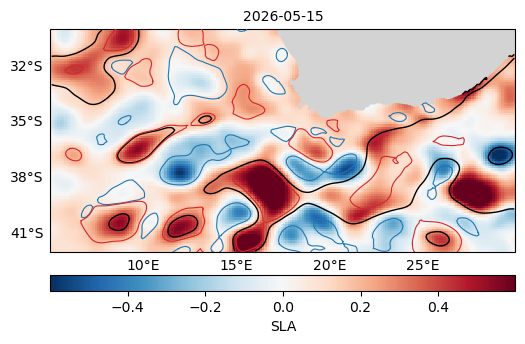

In [27]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

da = ds["sla"]
adt = ds["adt"]

lon_name = "longitude" if "longitude" in da.coords else "lon"
lat_name = "latitude" if "latitude" in da.coords else "lat"
time_name = "time"

vmax = float(np.nanpercentile(np.abs(da), 98))
levels = [-0.3, 0.7]

base = "https://thredds-x.ipsl.fr/thredds/fileServer/WHIRLS/PRODUCTS/TOEDDIES"

session = requests.Session()
session.headers.update({"User-Agent": "python-requests"})

def parse_geojson_polygons(gj):
    polygons = []

    for feat in gj["features"]:
        geom = feat["geometry"]

        if geom["type"] == "Polygon":
            for ring in geom["coordinates"]:
                ring = np.asarray(ring)
                polygons.append((ring[:, 0], ring[:, 1]))  # lon, lat

        elif geom["type"] == "MultiPolygon":
            for poly in geom["coordinates"]:
                for ring in poly:
                    ring = np.asarray(ring)
                    polygons.append((ring[:, 0], ring[:, 1]))  # lon, lat

    return polygons

eddy_data = {}

dates = pd.date_range("2026-05-15", "2026-06-03", freq="D")

for d in dates:
    date_str = d.strftime("%Y-%m-%d")

    cyclone_url = f"{base}/{date_str}_cyclones_outcontour.geojson"
    anticyclone_url = f"{base}/{date_str}_anticyclones_outcontour.geojson"

    day_data = {
        "cyclones": [],
        "anticyclones": [],
    }

    try:
        r = session.get(cyclone_url, timeout=60)
        r.raise_for_status()
        day_data["cyclones"] = parse_geojson_polygons(r.json())
    except requests.HTTPError:
        print(f"Missing cyclone file for {date_str}")
    except Exception as e:
        print(f"Error reading cyclone file for {date_str}: {e}")

    try:
        r = session.get(anticyclone_url, timeout=60)
        r.raise_for_status()
        day_data["anticyclones"] = parse_geojson_polygons(r.json())
    except requests.HTTPError:
        print(f"Missing anticyclone file for {date_str}")
    except Exception as e:
        print(f"Error reading anticyclone file for {date_str}: {e}")

    eddy_data[date_str] = day_data

fig = plt.figure(figsize=(6, 4))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(
    [westernmost_longitude, easternmost_longitude,
     southernmost_latitude, northernmost_latitude],
    crs=ccrs.PlateCarree()
)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)

gl = ax.gridlines(draw_labels=True, alpha=0)
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlocator = mticker.FixedLocator(
    np.arange(westernmost_longitude - 5, easternmost_longitude + 5, 5)
)
gl.ylocator = mticker.FixedLocator(
    np.arange(southernmost_latitude - 2, northernmost_latitude + 2, 3)
)

mesh = ax.pcolormesh(
    da[lon_name],
    da[lat_name],
    da.isel({time_name: 0}),
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    shading="auto",
    vmin=-vmax,
    vmax=vmax,
)

contours = ax.contour(
    adt[lon_name],
    adt[lat_name],
    adt.isel({time_name: 0}),
    levels=levels,
    colors="k",
    linewidths=1.0,
    transform=ccrs.PlateCarree(),
)

cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.075, aspect=30)
cbar.set_label("SLA")

title = ax.set_title(str(da[time_name].values[0])[:10], fontsize=10)

eddy_lines = []

def draw_eddy_lines(frame_date):
    lines = []

    cyclones = eddy_data.get(frame_date, {}).get("cyclones", [])
    anticyclones = eddy_data.get(frame_date, {}).get("anticyclones", [])

    for lon_poly, lat_poly in cyclones:
        line, = ax.plot(
            lon_poly,
            lat_poly,
            color="tab:blue",
            linewidth=0.8,
            linestyle="-",
            transform=ccrs.PlateCarree(),
            zorder=3,
        )
        lines.append(line)

    for lon_poly, lat_poly in anticyclones:
        line, = ax.plot(
            lon_poly,
            lat_poly,
            color="tab:red",
            linewidth=0.8,
            linestyle="-",
            transform=ccrs.PlateCarree(),
            zorder=3,
        )
        lines.append(line)

    return lines

initial_date = str(da[time_name].values[0])[:10]
eddy_lines = draw_eddy_lines(initial_date)

def update(i):
    global contours, eddy_lines

    field = da.isel({time_name: i}).values
    mesh.set_array(field.ravel())

    contours.remove()
    contours = ax.contour(
        adt[lon_name],
        adt[lat_name],
        adt.isel({time_name: i}),
        levels=levels,
        colors="k",
        linewidths=1.0,
        transform=ccrs.PlateCarree(),
    )

    for line in eddy_lines:
        line.remove()

    frame_date = str(da[time_name].values[i])[:10]
    eddy_lines = draw_eddy_lines(frame_date)

    title.set_text(frame_date)
    return [mesh, title, contours, *eddy_lines]

anim = animation.FuncAnimation(
    fig,
    update,
    frames=da.sizes[time_name],
    interval=100,
    blit=False
)

anim.save("sla_animation.gif", dpi=200, writer="pillow")